# 02 Process Metric Enrichment
This notebook explains the commit history features used by the model.
Process metrics describe how a file changed before the selected commit.

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
try:
    import seaborn as sns
    sns.set_theme(style="whitegrid")
except Exception:
    sns = None
WORKSPACE = Path.cwd().resolve().parent if Path.cwd().name == "notebooks" else Path.cwd().resolve()
DATA_PATH = WORKSPACE / "data" / "github_defect_dataset.csv"

## Optional enrichment command
Run this cell only when the dataset was created before process metrics were added.

In [ ]:
import subprocess
#Uncomment when you need to backfill process metrics
#subprocess.run(["python", "scripts/enrich_dataset_process_metrics.py"], cwd=WORKSPACE, check=True)

In [2]:
df = pd.read_csv(DATA_PATH)
process_columns = [
    "file_change_count",
    "file_bug_fix_count",
    "recent_file_change_count",
    "days_since_last_change",
    "last_change_churn",
    "last_change_file_count",
    "author_file_change_count",
]
available = [column for column in process_columns if column in df.columns]
df[available].describe().transpose()

,count,mean,std,min,25%,50%,75%,max
file_change_count,2797.0,66.138720,71.317652,0.0,9.0,33.0,115.0,199.0
file_bug_fix_count,2797.0,23.302824,31.005460,0.0,2.0,8.0,35.0,150.0
recent_file_change_count,2797.0,4.281373,10.866296,0.0,0.0,1.0,4.0,179.0
days_since_last_change,2797.0,669.643189,2203.341580,0.0,7.0,41.0,259.0,9999.0
last_change_churn,2797.0,25.707544,104.182805,0.0,2.0,6.0,17.0,3529.0
last_change_file_count,2797.0,591.317125,2096.316094,0.0,3.0,9.0,33.0,10209.0
author_file_change_count,2797.0,5.331069,14.668919,0.0,0.0,0.0,3.0,134.0


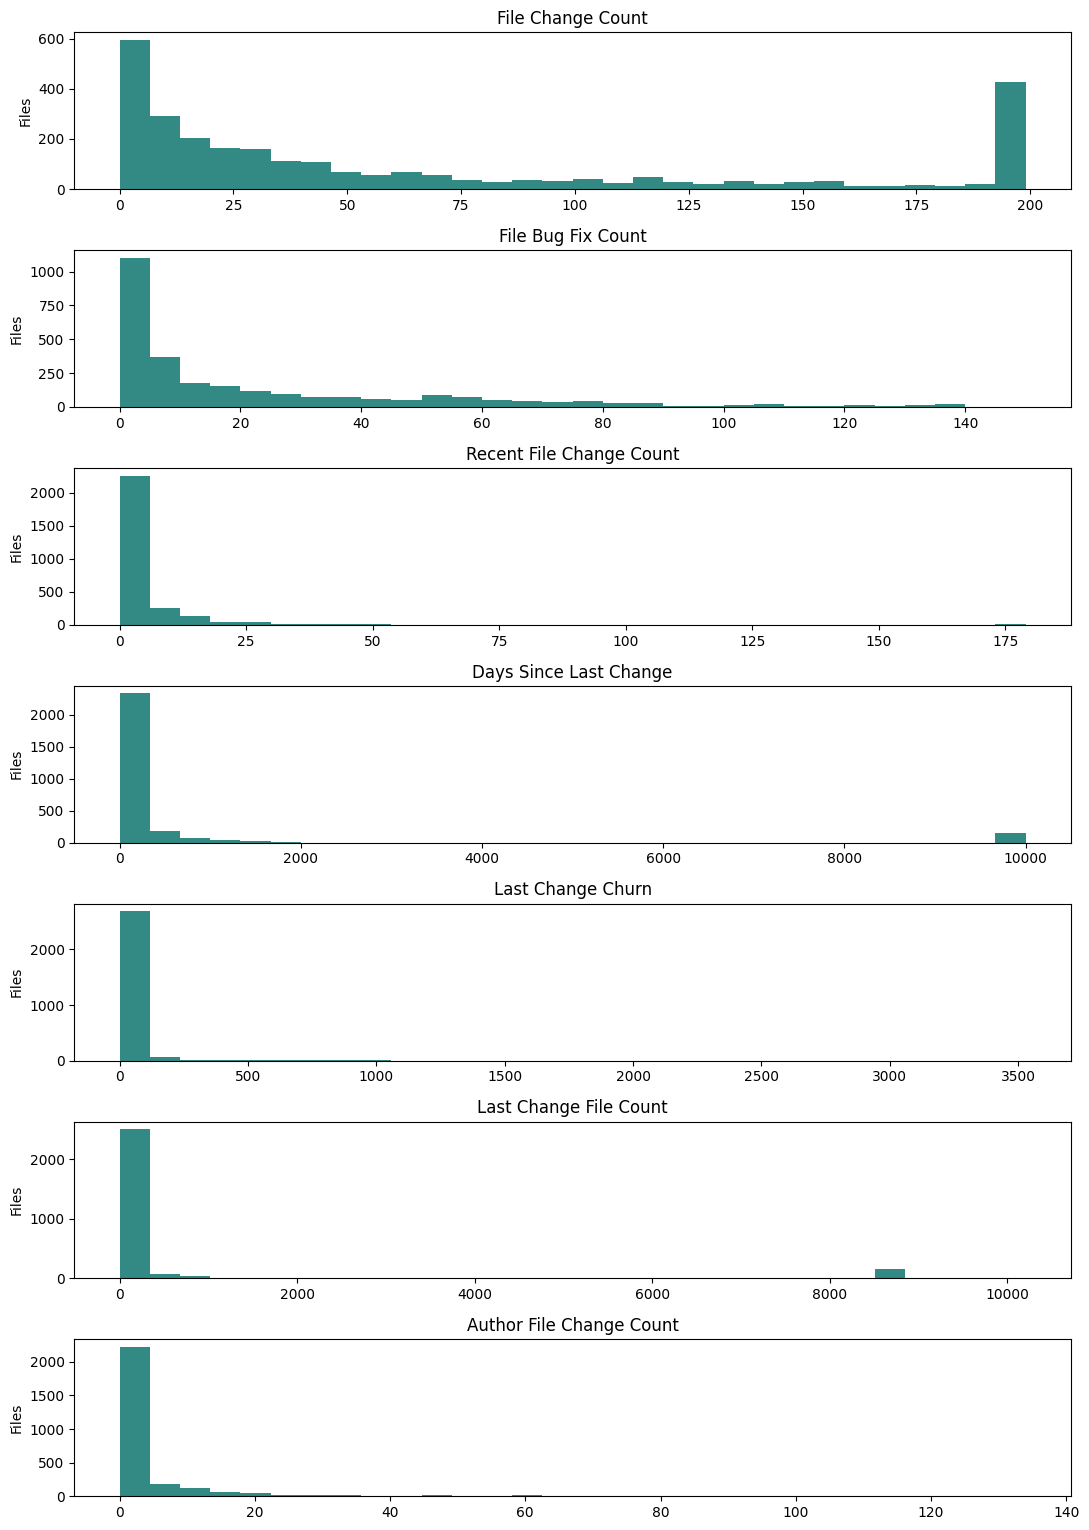

In [3]:
plot_df = df[available].copy()
fig, axes = plt.subplots(len(available), 1, figsize=(11, max(4, len(available) * 2.2)))
if len(available) == 1:
    axes = [axes]
for ax, column in zip(axes, available):
    ax.hist(plot_df[column].fillna(0), bins=30, color="#0f766e", alpha=0.85)
    ax.set_title(column.replace("_", " ").title())
    ax.set_ylabel("Files")
plt.tight_layout()
plt.show()